In [52]:
!pip install flask scikit-learn pandas numpy

In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [54]:
df = pd.read_csv('flood_data.csv')
df.head()

,subdivision,state,district,rainfall_mm,river_level_m,flood_level_m,flood_occurred,risk_level
0,Andaman & Nicobar Islands,Andaman & Nicobar Islands,Port Blair,49.2,0.4,0.3,0,Low
1,Arunachal Pradesh,Arunachal Pradesh,Itanagar,180.5,1.2,1.1,1,Medium
2,Assam & Meghalaya,Assam,Guwahati,245.0,2.8,2.6,1,High
3,Assam & Meghalaya,Meghalaya,Shillong,245.0,2.8,2.6,1,High
4,Nagaland-Manipur-Mizoram-Tripura,Nagaland,Kohima,115.0,0.9,0.7,0,Low


In [55]:
required_cols = {'rainfall_mm', 'river_level_m', 'flood_level_m', 'risk_level'}

missing = required_cols - set(df.columns)

if missing:
    raise ValueError(f"Dataset missing columns: {missing}")
else:
    print("✅ Dataset is valid")

✅ Dataset is valid


In [56]:

features = ['rainfall_mm', 'river_level_m', 'flood_level_m']
X = df[features].values
y = df['risk_level'].values


In [57]:

le = LabelEncoder()
y_enc = le.fit_transform(y)


In [58]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [59]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42
)

print("✅ Preprocessing done")

✅ Preprocessing done


In [60]:

knn = KNeighborsClassifier(n_neighbors=3)
dt = DecisionTreeClassifier(max_depth=4)
lr = LogisticRegression(max_iter=500)


In [61]:

knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
lr.fit(X_train, y_train)

print("✅ Models trained")

✅ Models trained


In [62]:
MODELS = {
    'KNN': knn,
    'Decision Tree': dt,
    'Logistic Regression': lr
}

model_accuracies = {}


In [63]:

for name, model in MODELS.items():
    acc = accuracy_score(y_test, model.predict(X_test)) * 100
    model_accuracies[name] = round(acc, 2)


model_accuracies

{'KNN': 77.78, 'Decision Tree': 88.89, 'Logistic Regression': 88.89}

In [64]:
def predict_flood(rainfall, river_level, flood_level, model_name='KNN'):

    model = MODELS.get(model_name, knn)

    X_input = scaler.transform([[rainfall, river_level, flood_level]])

    pred = model.predict(X_input)[0]
    probs = model.predict_proba(X_input)[0]

    label = le.inverse_transform([pred])[0]
    classes = list(le.classes_)

    prob_dict = {
        classes[i]: round(float(p) * 100, 2)
        for i, p in enumerate(probs)
    }

    score_map = {'Low': 25, 'Medium': 60, 'High': 90}

    result = {
        "risk_level": label,
        "risk_score": score_map.get(label, 50),
        "probabilities": prob_dict,
        "model_used": model_name,
        "model_accuracy": model_accuracies.get(model_name, None),
        "flood_likely": label != "Low"
    }

    return result

In [65]:

result = predict_flood(
    rainfall=120,
    river_level=5.5,
    flood_level=6.0,
    model_name='KNN'
)

result

{'risk_level': 'High',
 'risk_score': 90,
 'probabilities': {'High': 100.0, 'Low': 0.0, 'Medium': 0.0},
 'model_used': 'KNN',
 'model_accuracy': 77.78,
 'flood_likely': True}

In [66]:
names = list(model_accuracies.keys())
values = list(model_accuracies.values())

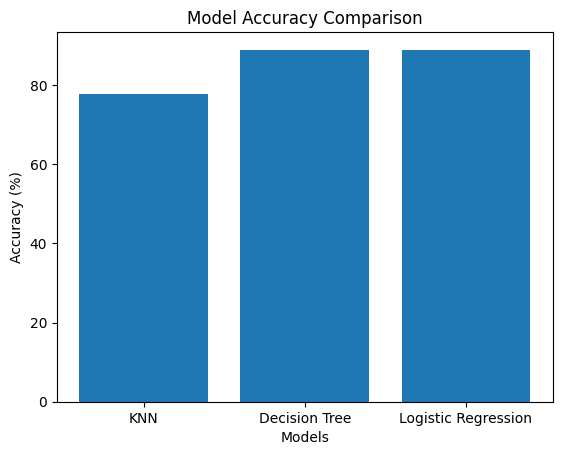

In [67]:
plt.figure()
plt.bar(names, values)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.show()